In [2]:
# Import public packages and functions
import os
import pandas as pd
import numpy as np
import sys
import json
from pathlib import Path

import seaborn as sns
import matplotlib.pyplot as plt
import scikit_posthocs as sp

import warnings
warnings.filterwarnings("ignore")

# inserting the lib folder to the compiler
sys.path.insert(0, './lib')
sys.path.insert(0, './utils/')

import utils_misc, utils_io, utils_plotting, utils_mutual_information, utils_statistics, utils_spectrogram, utils_plotting_spectrogram
from lib_data import DATA_IO

fs                  = 2048
PATH_CURR           = os.path.abspath(os.curdir)    # current code
PATH                = (str(Path(PATH_CURR).parent)) # data repository: upper directory where datasets situate

# 1. Calculate Tap-Wise Time-Frequency Activity

In [14]:
df_TAPPING_events   = pd.read_pickle(DATA_IO.path_events + "ECoG_EVENTS.pkl")

## LID severity 3: noLID_noDOPA, noLID_DOPA, LID
df_TAPPING_events["severity"] = df_TAPPING_events.dyskinesia_arm.copy()
df_TAPPING_events.loc[(df_TAPPING_events['severity']!= "none") , "severity"]                                                 = 'LID'
df_TAPPING_events.loc[(df_TAPPING_events['severity']== "none") & (df_TAPPING_events['event_start_time'] <= 30 ), "severity"] = 'noLID_noDOPA'
df_TAPPING_events.loc[(df_TAPPING_events['severity']== "none") & (df_TAPPING_events['event_start_time'] > 30 ) , "severity"] = 'noLID_DOPA'

df_controlateral    = df_TAPPING_events[df_TAPPING_events.event_laterality != df_TAPPING_events.ECoG_hemisphere]
df_controlateral    = utils_misc.get_onset_and_offset_aligned_recordings(df_controlateral, fs=fs)
df_controlateral    = df_controlateral[["patient", "event_no", "ECoG_hemisphere", "ECoG_channel", "recording_onset_aligned","recording_offset_aligned","severity"]]
df_controlateral.reset_index(inplace=True, drop=True)

baseline_recordings = utils_io.load_baseline_recordings(recording_type="ECoG")

Patient 008: does not have right hemisphere baseline recordings
Patient 009: does not have right hemisphere baseline recordings
Patient 010: does not have left hemisphere baseline recordings
Patient 012: does not have left hemisphere baseline recordings
Patient 013: does not have left hemisphere baseline recordings
Patient 014: does not have left hemisphere baseline recordings
Patient 016: does not have left hemisphere baseline recordings
Patient 017: does not have left hemisphere baseline recordings
Patient 020: does not have left hemisphere baseline recordings
Patient 021: does not have left hemisphere baseline recordings
Patient 022: does not have left hemisphere baseline recordings
Patient 023: does not have left hemisphere baseline recordings
Patient 101: does not have right hemisphere baseline recordings
Patient 101: does not have left hemisphere baseline recordings
Patient 102: does not have right hemisphere baseline recordings
Patient 102: does not have left hemisphere baseline

In [17]:
dataset               = pd.DataFrame(df_controlateral)
dataset["hemisphere"] = dataset.ECoG_hemisphere
dataset["channel"]    = dataset.ECoG_channel
dataset.reset_index(inplace=True, drop=True)

df_spectrogram        = utils_spectrogram.measure_normalized_multitaper_spectrograms_for_taps_and_channels(dataset, fs, baseline_recordings)
df_spectrogram.to_pickle(DATA_IO.path_events + "time_frequency_activity/ECOG_TFA") 

Patient 008
---> baseline TFR measurement is completed...
------> left - LID - p_008_right_tapping1
------> left - LID - p_008_right_tapping2
------> left - LID - p_008_right_tapping3
------> left - LID - p_008_right_tapping4
------> left - LID - p_008_right_tapping5
------> left - LID - p_008_right_tapping6
------> left - LID - p_008_right_tapping7
------> left - LID - p_008_right_tapping8
------> left - LID - p_008_right_tapping9
------> left - LID - p_008_right_tapping10
------> left - LID - p_008_right_tapping11
------> left - LID - p_008_right_tapping12
------> left - LID - p_008_right_tapping13
------> left - LID - p_008_right_tapping14
------> left - LID - p_008_right_tapping15
------> left - LID - p_008_right_tapping16
------> left - LID - p_008_right_tapping17
------> left - LID - p_008_right_tapping18
------> left - LID - p_008_right_tapping19
------> left - LID - p_008_right_tapping20
------> left - LID - p_008_right_tapping21
------> left - LID - p_008_right_tapping22
-----

# 2. Load Channel and Severity-Wise Time-Frequency Activity

In [3]:
df_spectrogram              = pd.read_pickle(DATA_IO.path_events + "time_frequency_activity/ECOG_TFA") 
df_spectrogram_LID          = df_spectrogram[df_spectrogram.severity=="LID"]
df_spectrogram_noLID_noDOPA = df_spectrogram[df_spectrogram.severity=="noLID_noDOPA"]
df_spectrogram_noLID_DOPA   = df_spectrogram[df_spectrogram.severity=="noLID_DOPA"]

# 3. Plot Spectrograms

In [13]:
def average_spectrograms_per_event(dataset, alignment):
    
    averaged_rows = []
    grouped       = dataset[dataset.alignment_type==alignment].groupby(["patient", "hemisphere", "severity", "event_no", "alignment_type"])

    for (patient, hemisphere, severity, event_no, alignment_type), group in grouped:
        
        spectrograms      = np.stack(group["spectrogram"].values)  # stack all spectrograms from different channels
        mean_spectrograms = np.nanmean(spectrograms, axis=0)       # take the mean across channels (axis=0)
        averaged_rows.append({"patient": patient, "hemisphere": hemisphere, "severity": severity, "event_no": event_no, "spectrogram_mean": mean_spectrograms})

    df_mean = pd.DataFrame(averaged_rows)
    
    return df_mean

In [15]:
TFR_avg_offset_noLID_noDOPA = average_spectrograms_per_event(df_spectrogram_noLID_noDOPA, alignment="offset")
TFR_avg_offset_noLID_noDOPA = np.nanmean(np.stack(TFR_avg_offset_noLID_noDOPA["spectrogram_mean"].values), axis=0)
TFR_avg_offset_noLID_DOPA   = average_spectrograms_per_event(df_spectrogram_noLID_DOPA, alignment="offset")
TFR_avg_offset_noLID_DOPA   = np.nanmean(np.stack(TFR_avg_offset_noLID_DOPA["spectrogram_mean"].values), axis=0)
TFR_avg_offset_LID          = average_spectrograms_per_event(df_spectrogram_LID, alignment="offset")
TFR_avg_offset_LID          = np.nanmean(np.stack(TFR_avg_offset_LID["spectrogram_mean"].values), axis=0)

In [17]:
TFR_avg_onset_noLID_noDOPA  = average_spectrograms_per_event(df_spectrogram_noLID_noDOPA, alignment="onset")
TFR_avg_onset_noLID_noDOPA  = np.nanmean(np.stack(TFR_avg_onset_noLID_noDOPA["spectrogram_mean"].values), axis=0)
TFR_avg_onset_noLID_DOPA    = average_spectrograms_per_event(df_spectrogram_noLID_DOPA, alignment="onset")
TFR_avg_onset_noLID_DOPA    = np.nanmean(np.stack(TFR_avg_onset_noLID_DOPA["spectrogram_mean"].values), axis=0)
TFR_avg_onset_LID           = average_spectrograms_per_event(df_spectrogram_LID, alignment="onset")
TFR_avg_onset_LID           = np.nanmean(np.stack(TFR_avg_onset_LID["spectrogram_mean"].values), axis=0)

<Figure size 640x480 with 0 Axes>

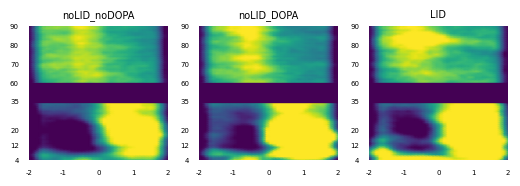

In [34]:
plt             = utils_plotting.get_figure_template()
ax_noLID_noDOPA = plt.subplot2grid((80, 40), (0, 0) , colspan=10, rowspan=17)
ax_noLID_DOPA   = plt.subplot2grid((80, 40), (0, 12) , colspan=10, rowspan=17)
ax_LID          = plt.subplot2grid((80, 40), (0, 24), colspan=10, rowspan=17)

ax_noLID_noDOPA = utils_plotting_spectrogram.plot_mean_spectrogram(TFR_avg_offset_noLID_noDOPA, group = "noLID_noDOPA", time_vector=np.linspace(-2,2,40), 
                                                                   vmin=-30, vmax=30, cmap="viridis", axis=ax_noLID_noDOPA)
ax_noLID_DOPA   = utils_plotting_spectrogram.plot_mean_spectrogram(TFR_avg_offset_noLID_DOPA, group = "noLID_DOPA", time_vector=np.linspace(-2,2,40), 
                                                                   vmin=-30, vmax=30, cmap="viridis", axis=ax_noLID_DOPA)
ax_LID          = utils_plotting_spectrogram.plot_mean_spectrogram(TFR_avg_offset_LID, group = "LID", time_vector=np.linspace(-2,2,40), 
                                                                   vmin=-30, vmax=30, cmap="viridis", axis=ax_LID)

plt.savefig(DATA_IO.path_figure + "spectrogram/cortex_spectrogram_offset.svg", dpi=1200)

<Figure size 640x480 with 0 Axes>

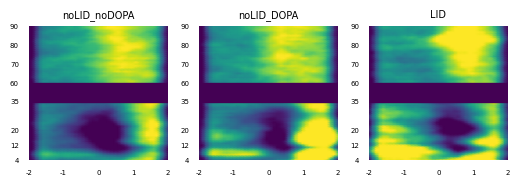

In [36]:
plt             = utils_plotting.get_figure_template()
ax_noLID_noDOPA = plt.subplot2grid((80, 40), (0, 0) , colspan=10, rowspan=17)
ax_noLID_DOPA   = plt.subplot2grid((80, 40), (0, 12) , colspan=10, rowspan=17)
ax_LID          = plt.subplot2grid((80, 40), (0, 24), colspan=10, rowspan=17)

ax_noLID_noDOPA = utils_plotting_spectrogram.plot_mean_spectrogram(TFR_avg_onset_noLID_noDOPA, group = "noLID_noDOPA", time_vector=np.linspace(-2,2,40), 
                                                                   vmin=-30, vmax=30, cmap="viridis", axis=ax_noLID_noDOPA)
ax_noLID_DOPA   = utils_plotting_spectrogram.plot_mean_spectrogram(TFR_avg_onset_noLID_DOPA, group = "noLID_DOPA", time_vector=np.linspace(-2,2,40), 
                                                                   vmin=-30, vmax=30, cmap="viridis", axis=ax_noLID_DOPA)
ax_LID          = utils_plotting_spectrogram.plot_mean_spectrogram(TFR_avg_onset_LID, group = "LID", time_vector=np.linspace(-2,2,40), 
                                                                   vmin=-30, vmax=30, cmap="viridis", axis=ax_LID)

plt.savefig(DATA_IO.path_figure + "spectrogram/cortex_spectrogram_onset.svg", dpi=1200)